In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import norm
from itertools import product





def melhor_sazonalidade(
    serie,
    m_min=2,
    m_max=30,
    robust=True,
    plot=True
):
    
    resultados = []
    
    for m in range(m_min, m_max + 1):
        
        try:
            
            stl = STL(
                serie,
                period=m,
                robust=robust
            ).fit()
            
            forca_sazonalidade = 1 - (
                np.var(stl.resid) /
                np.var(stl.seasonal + stl.resid)
            )
            
            resultados.append({
                'm': m,
                'forca_sazonalidade': forca_sazonalidade
            })
        
        except:
            pass
    
    resultados = pd.DataFrame(resultados)
    
    melhor_m = resultados.loc[
        resultados['forca_sazonalidade'].idxmax()
    ]
    
    print('=' * 50)
    print(f"Melhor m: {int(melhor_m['m'])}")
    print(
        f"Força da sazonalidade: "
        f"{melhor_m['forca_sazonalidade']:.4f}"
    )
    print('=' * 50)
    
    if plot:
        
        plt.figure(figsize=(12,5))
        
        plt.plot(
            resultados['m'],
            resultados['forca_sazonalidade'],
            marker='o'
        )
        
        plt.axvline(
            melhor_m['m'],
            linestyle='--'
        )
        
        plt.title('Força da Sazonalidade por m')
        plt.xlabel('m')
        plt.ylabel('Força da Sazonalidade')
        plt.grid(True)
        plt.show()
    
    return resultados, int(melhor_m['m'])

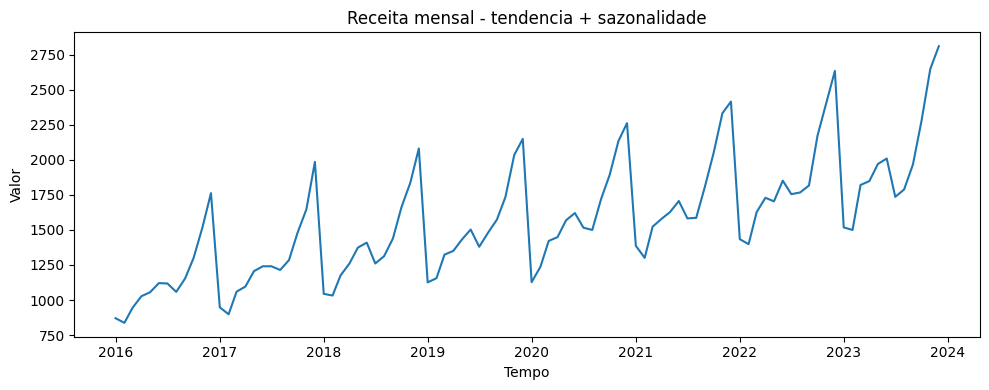

In [2]:
df = pd.read_excel('dados_aula10_holtwinters.xlsx', parse_dates=['mes'], index_col='mes')

df.head()

plt.figure(figsize=(10, 4))
plt.plot(df)
plt.title(f'Receita mensal - tendencia + sazonalidade')
plt.xlabel('Tempo'); plt.ylabel('Valor')
plt.tight_layout(); plt.show()

Melhor m: 12
Força da sazonalidade: 0.9884


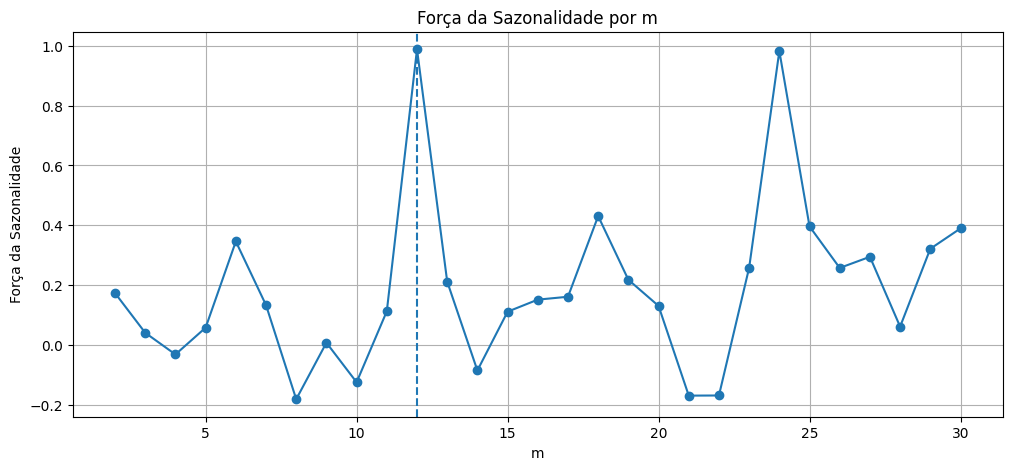

(     m  forca_sazonalidade
 0    2            0.172920
 1    3            0.040209
 2    4           -0.032159
 3    5            0.057473
 4    6            0.345715
 5    7            0.132743
 6    8           -0.181853
 7    9            0.007135
 8   10           -0.125174
 9   11            0.112269
 10  12            0.988424
 11  13            0.211471
 12  14           -0.085748
 13  15            0.110789
 14  16            0.151120
 15  17            0.160773
 16  18            0.430453
 17  19            0.217593
 18  20            0.130153
 19  21           -0.169814
 20  22           -0.169364
 21  23            0.257782
 22  24            0.982319
 23  25            0.395985
 24  26            0.257127
 25  27            0.294350
 26  28            0.060770
 27  29            0.321206
 28  30            0.389260,
 12)

In [3]:
melhor_sazonalidade(df['receita'], m_min=2, m_max=30, robust=True, plot=True)

In [4]:
h = 12
train = df['receita'].iloc[:-h]
test = df['receita'].iloc[-h:]

AIC (SES): 954.47
MAE (SES): 665.14


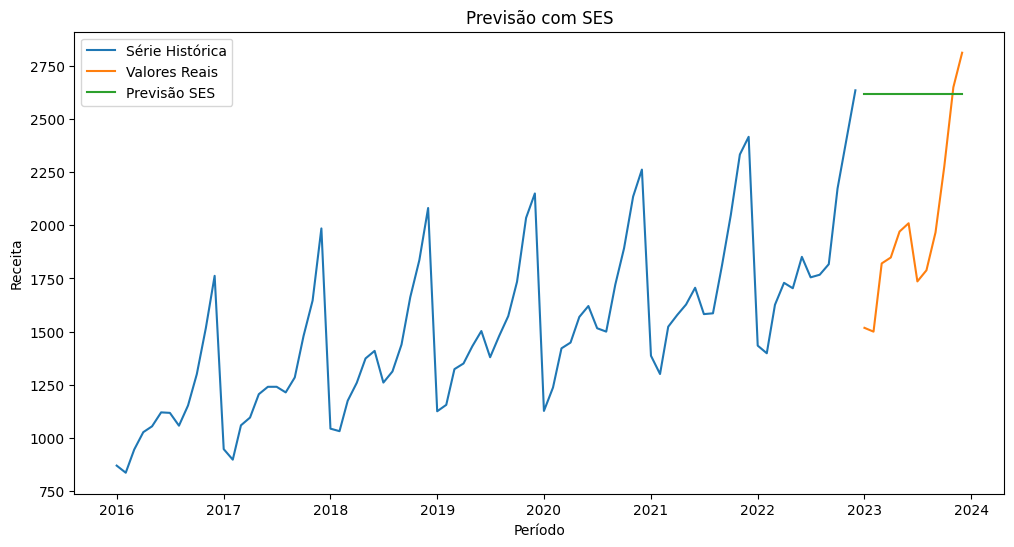

In [5]:
ses = exponential_smoothing = ExponentialSmoothing(train, trend=None, seasonal=None, initialization_method="heuristic").fit()
fc_ses = ses.forecast(h)
mae_ses = mean_absolute_error(test, fc_ses)

print(f'AIC (SES): {ses.aic:.2f}')
print(f'MAE (SES): {mae_ses:.2f}')

plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Série Histórica')
plt.plot(test.index, test.values, label='Valores Reais')
plt.plot(test.index, fc_ses, label='Previsão SES')
plt.legend()
plt.title('Previsão com SES')
plt.xlabel('Período')
plt.ylabel('Receita')
plt.show()



AIC (Holt-Winters Aditivo): 693.77
MAE (Holt-Winters Aditivo): 71.21


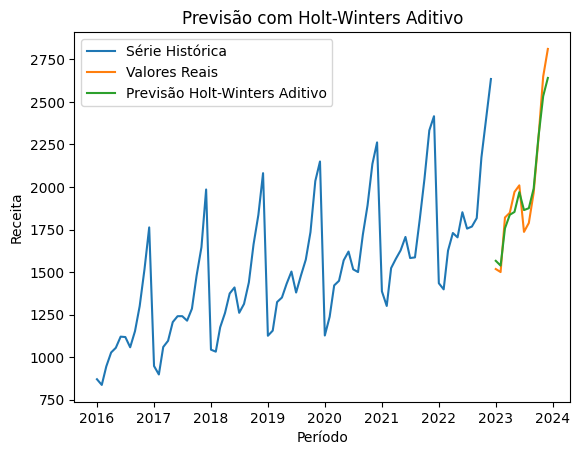

In [6]:
hw_add = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, initialization_method="heuristic").fit()

print(f"AIC (Holt-Winters Aditivo): {hw_add.aic:.2f}")
print(f"MAE (Holt-Winters Aditivo): {mean_absolute_error(test, hw_add.forecast(h)):.2f}")

#plot serie x previsao
plt.plot(train.index, train.values, label='Série Histórica')
plt.plot(test.index, test.values, label='Valores Reais')
plt.plot(test.index, hw_add.forecast(h), label='Previsão Holt-Winters Aditivo')
plt.legend()
plt.title('Previsão com Holt-Winters Aditivo')
plt.xlabel('Período')
plt.ylabel('Receita')
plt.show()


AIC (Holt-Winters Multiplicativo): 681.78 | aditivo: 693.77
BIC (Holt-Winters Multiplicativo): 720.67 | aditivo: 732.67


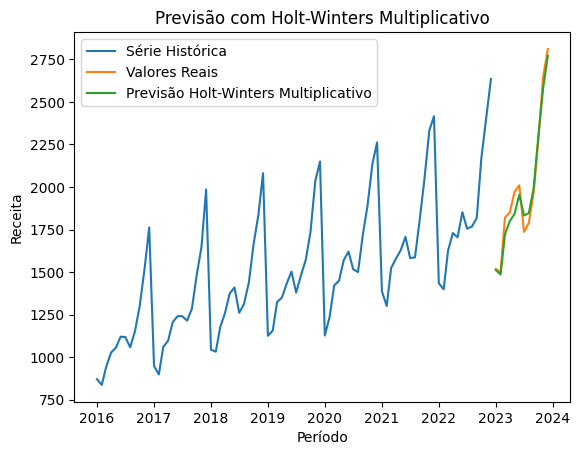

In [7]:
hw_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12, initialization_method="heuristic").fit()

print(f"AIC (Holt-Winters Multiplicativo): {hw_mul.aic:.2f} | aditivo: {hw_add.aic:.2f}") 
print(f"BIC (Holt-Winters Multiplicativo): {hw_mul.bic:.2f} | aditivo: {hw_add.bic:.2f}")

plt.plot(train.index, train.values, label='Série Histórica')
plt.plot(test.index, test.values, label='Valores Reais')
plt.plot(test.index, hw_mul.forecast(h), label='Previsão Holt-Winters Multiplicativo')
plt.legend()
plt.title('Previsão com Holt-Winters Multiplicativo')
plt.xlabel('Período')
plt.ylabel('Receita')
plt.show()

MAE (SES): 665.14
MAE (Holt-Winters Aditivo): 71.21
MAE (Holt-Winters Multiplicativo): 55.12


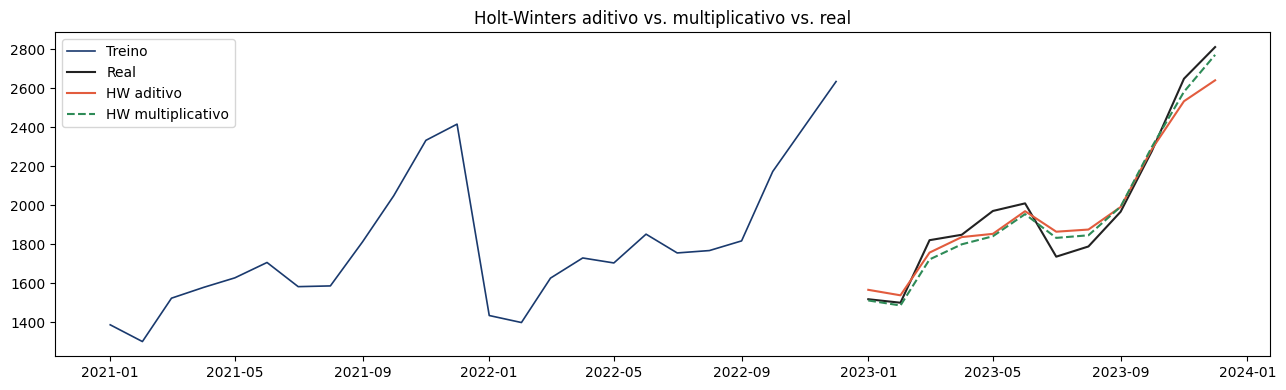

In [8]:
fc_add = hw_add.forecast(h)
fc_mul = hw_mul.forecast(h)

mae_add = mean_absolute_error(test, fc_add)
mae_mul = mean_absolute_error(test, fc_mul)

print(f"MAE (SES): {mae_ses:.2f}")
print(f"MAE (Holt-Winters Aditivo): {mae_add:.2f}")
print(f"MAE (Holt-Winters Multiplicativo): {mae_mul:.2f}")

fig, ax = plt.subplots (figsize=(13, 4))
ax.plot(train[-24:].index, train [-24:], label='Treino', color='#1a3a6e', linewidth=1.2)
ax.plot(test.index, test, label='Real', color='#222', linewidth=1.5)
ax.plot(fc_add.index, fc_add, '', label='HW aditivo', color='#e25c3e', linewidth=1.5)
ax.plot(fc_mul.index, fc_mul, '--', label='HW multiplicativo', color='#2e8b57', linewidth=1.5)
ax.set_title('Holt-Winters aditivo vs. multiplicativo vs. real')
ax.legend()
plt.tight_layout()
plt.show()

Parâmetros estimados (Holt-Winters multiplicativo):
 smoothing_level      = 0.0767
 smoothing_trend      = 0.0076
 smoothing_seasonal   = 0.4320


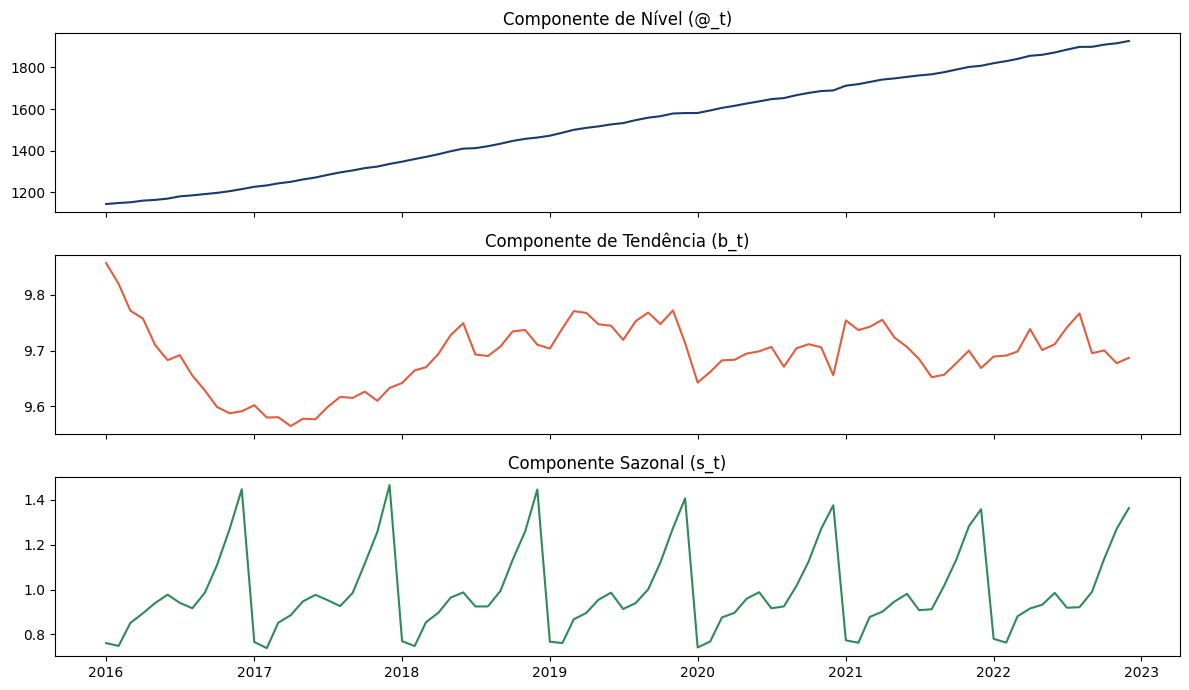

In [9]:
params = hw_mul.params
print("Parâmetros estimados (Holt-Winters multiplicativo):")

for nome in ["smoothing_level", "smoothing_trend", "smoothing_seasonal"]:
    print(f" {nome: <20} = {params[nome]:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(train.index, hw_mul.level, color='#1a3a6e')
axes[0].set_title('Componente de Nível (@_t)')
axes[1].plot(train.index, hw_mul.trend, color='#e25c3e')
axes[1].set_title('Componente de Tendência (b_t)')
axes[2].plot(train.index, hw_mul.season, color='#2e8b57')
axes[2].set_title('Componente Sazonal (s_t)')
plt.tight_layout()
plt.show()

In [10]:
sarima = SARIMAX(
train, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

fc_sarima = sarima.get_forecast(steps=h).predicted_mean
mae_sarima = mean_absolute_error(test, fc_sarima)
print(f"AIC SARIMA: {sarima.aic:.2f} | BIC SARIMA: {sarima.bic:.2f} | MAE SARIMA: {mae_sarima:.2f}")

AIC SARIMA: 622.96 | BIC SARIMA: 631.13 | MAE SARIMA: 63.48


In [11]:
resultados = pd. DataFrame({
    "modelo": ["SES", "HW aditivo", "HW multiplicativo", "SARIMA"],
    "AIC": [ses.aic, hw_add.aic, hw_mul.aic, sarima.aic],
    "BIC": [ses.bic, hw_add.bic, hw_mul.bic, sarima.bic],
    "MAE": [mae_ses, mae_add, mae_mul, mae_sarima]
}).sort_values("MAE")

print(resultados.round(2).to_string(index=False))
print(f"\nMelhor modelo por MAE out-of-sample: {resultados.iloc[0]['modelo']}")

           modelo    AIC    BIC    MAE
HW multiplicativo 681.78 720.67  55.12
           SARIMA 622.96 631.13  63.48
       HW aditivo 693.77 732.67  71.21
              SES 954.47 959.33 665.14

Melhor modelo por MAE out-of-sample: HW multiplicativo


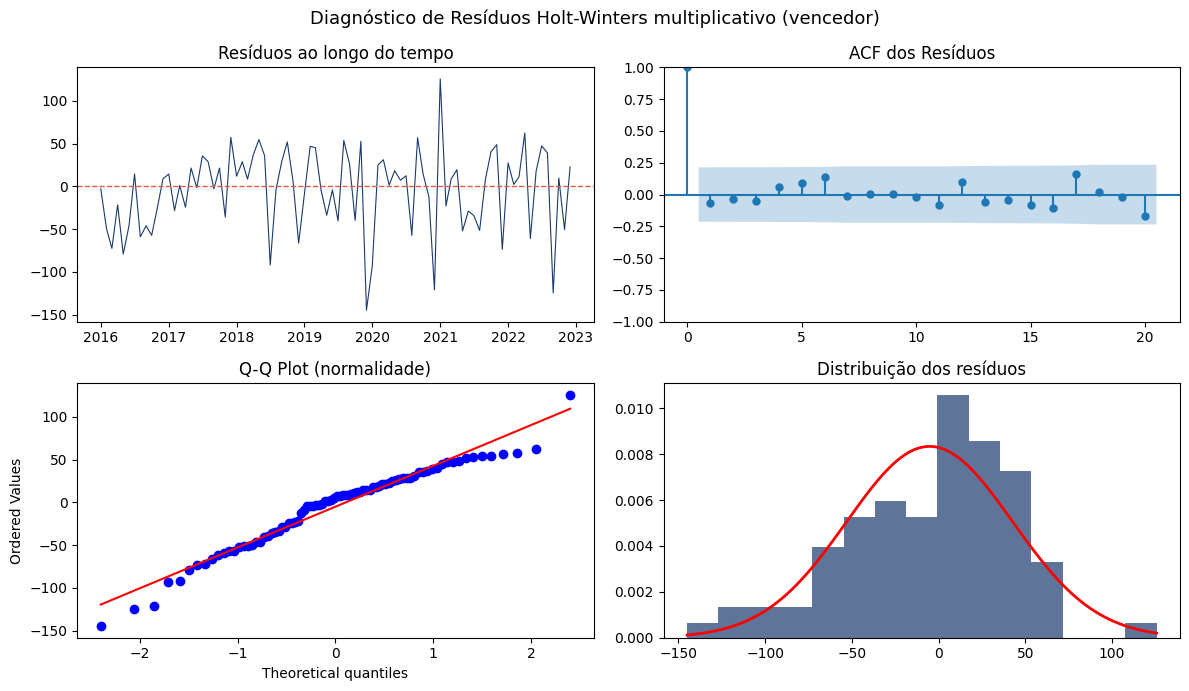

Ljung-Box (H0: resíduos sem autocorrelação):
    lb_stat  lb_pvalue
1    0.3417     0.5588
2    0.4629     0.7934
3    0.7233     0.8677
4    1.0146     0.9076
5    1.8109     0.8746
6    3.4899     0.7453
7    3.4991     0.8353
8    3.5019     0.8990
9    3.5077     0.9407
10   3.5444     0.9656
11   4.1579     0.9651
12   5.1142     0.9541


In [12]:
resid = hw_mul.resid.dropna()

fig, axes = plt.subplots (2, 2, figsize=(12, 7))

axes[0, 0].plot(resid.index, resid, color="#1a3a6e", linewidth=0.8)
axes[0, 0].axhline (0, color="#e25c3e", linewidth=1, linestyle="--")
axes[0, 0].set_title("Resíduos ao longo do tempo")

plot_acf(resid, lags=20, ax=axes [0, 1], title="ACF dos Resíduos")

stats.probplot(resid, dist="norm", plot=axes [1, 0])
axes[1, 0].set_title("Q-Q Plot (normalidade)")

axes[1, 1].hist(resid, bins=15, density=True, color="#1a3a6e", alpha=0.7)
x = np.linspace(resid.min(), resid.max(), 200)
axes[1, 1].plot(x, norm.pdf(x, resid.mean(), resid.std()), "r-", linewidth=2)
axes[1, 1].set_title("Distribuição dos resíduos")

plt.suptitle("Diagnóstico de Resíduos Holt-Winters multiplicativo (vencedor)", fontsize=13) 
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=12, return_df=True)
print("Ljung-Box (H0: resíduos sem autocorrelação):")
print(lb[["lb_stat", "lb_pvalue"]].round(4))
todos_ok = (lb["lb_pvalue"] > 0.05).all()

Top 10 melhores combinações de parâmetros (por AIC):
    order seasonal_order        AIC        BIC
(0, 1, 2)  (0, 1, 1, 12) 613.538446 621.639853
(1, 1, 2)  (0, 1, 1, 12) 614.825972 624.952730
(0, 1, 2)  (1, 1, 1, 12) 615.296074 625.422832
(2, 1, 2)  (0, 1, 1, 12) 616.475639 628.627749
(1, 1, 2)  (1, 1, 1, 12) 617.029279 629.181389
(2, 1, 2)  (1, 1, 1, 12) 618.708986 632.886448
(0, 1, 1)  (0, 1, 1, 12) 620.997655 627.126809
(1, 1, 1)  (0, 1, 1, 12) 622.958354 631.130559
(0, 1, 1)  (1, 1, 1, 12) 623.572012 631.744217
(2, 1, 1)  (0, 1, 1, 12) 624.584406 634.799663

Melhores parâmetros SARIMA: order=(0, 1, 2), seasonal_order=(0, 1, 1, 12)
Melhor AIC: 613.54


MAE SARIMA (otimizado): 63.63

Comparação:
MAE HW multiplicativo: 55.12
MAE SARIMA (otimizado): 63.63
Melhoria: -15.44%


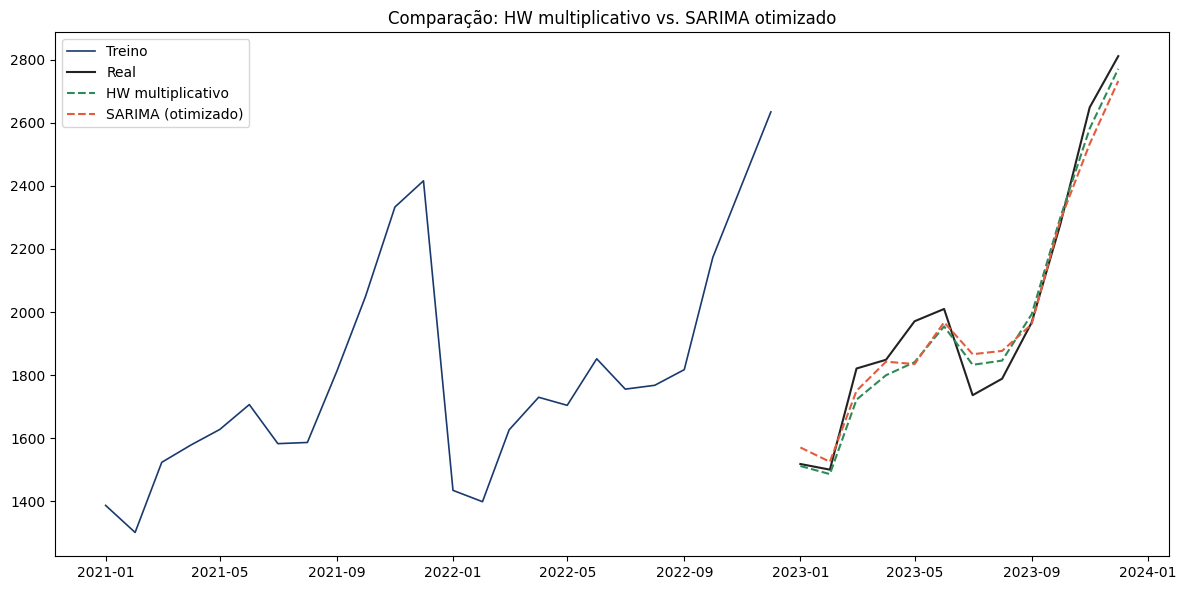

In [13]:
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)
P_range = range(0, 2)
D_range = range(0, 2)
Q_range = range(0, 2)

best_aic = np.inf
best_params = None
results_grid = []

# Grid Search
for p, d, q, P, D, Q in product(p_range, d_range, q_range, P_range, D_range, Q_range):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
        results_grid.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, 12),
            'AIC': model.aic,
            'BIC': model.bic
        })
        
        if model.aic < best_aic:
            best_aic = model.aic
            best_params = (p, d, q, P, D, Q)
    
    except:
        pass

# Criar DataFrame com resultados
grid_results = pd.DataFrame(results_grid).sort_values('AIC')

print("Top 10 melhores combinações de parâmetros (por AIC):")
print(grid_results.head(10).to_string(index=False))
print(f"\nMelhores parâmetros SARIMA: order={best_params[:3]}, seasonal_order={best_params[3:]+(12,)}")
print(f"Melhor AIC: {best_aic:.2f}")

# Treinar modelo com melhores parâmetros
sarima_best = SARIMAX(
    train,
    order=best_params[:3],
    seasonal_order=best_params[3:]+(12,),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc_sarima_best = sarima_best.get_forecast(steps=h).predicted_mean
mae_sarima_best = mean_absolute_error(test, fc_sarima_best)

print(f"MAE SARIMA (otimizado): {mae_sarima_best:.2f}")

# Comparar com Holt-Winters multiplicativo
print(f"\nComparação:")
print(f"MAE HW multiplicativo: {mae_mul:.2f}")
print(f"MAE SARIMA (otimizado): {mae_sarima_best:.2f}")
print(f"Melhoria: {((mae_mul - mae_sarima_best) / mae_mul * 100):.2f}%")

# Plotar previsões
plt.figure(figsize=(12, 6))
plt.plot(train[-24:].index, train[-24:], label='Treino', color='#1a3a6e', linewidth=1.2)
plt.plot(test.index, test, label='Real', color='#222', linewidth=1.5)
plt.plot(fc_mul.index, fc_mul, '--', label='HW multiplicativo', color='#2e8b57', linewidth=1.5)
plt.plot(fc_sarima_best.index, fc_sarima_best, '--', label='SARIMA (otimizado)', color='#e25c3e', linewidth=1.5)
plt.title('Comparação: HW multiplicativo vs. SARIMA otimizado')
plt.legend()
plt.tight_layout()
plt.show()

## Desafio - Tendência amortecida (`damped_trend`)

Comparação do Holt-Winters multiplicativo sem amortecimento, com φ estimado automaticamente por máxima verossimilhança e com valores fixos de φ. O horizonte de previsão é de 36 meses.

In [14]:
# Horizonte longo solicitado no desafio
h_longo = 36
phis = [0.99, 0.95, 0.90, 0.85, 0.80, 0.70]

# Modelo de referência: tendência não amortecida
hw_mul_sem_damping = ExponentialSmoothing(
    train, trend='add', seasonal='mul', seasonal_periods=12,
    damped_trend=False, initialization_method='heuristic'
).fit()
fc_sem_damping = hw_mul_sem_damping.forecast(h_longo)

# Modelo com phi estimado automaticamente por MLE
hw_mul_damped = ExponentialSmoothing(
    train, trend='add', seasonal='mul', seasonal_periods=12,
    damped_trend=True, initialization_method='heuristic'
).fit()
phi_mle = hw_mul_damped.params['damping_trend']
fc_mle = hw_mul_damped.forecast(h_longo)

# Ajustes com phi fixo
modelos_fixos = {}
linhas = []
valor_base = float(fc_sem_damping.iloc[-1])

for phi in phis:
    modelo = ExponentialSmoothing(
        train, trend='add', seasonal='mul', seasonal_periods=12,
        damped_trend=True, initialization_method='heuristic'
    ).fit(damping_trend=phi)
    previsao = modelo.forecast(h_longo)
    modelos_fixos[phi] = (modelo, previsao)
    valor_mes_36 = float(previsao.iloc[-1])
    linhas.append({
        'phi': phi,
        'valor_mes_36': valor_mes_36,
        'variacao_%_vs_sem_damping': 100 * (valor_mes_36 / valor_base - 1),
        'AIC': modelo.aic
    })

tabela_damping = pd.DataFrame(linhas)
print(f'Phi automático (MLE): {phi_mle:.4f}')
print(f'Valor no mês 36 sem damping: {valor_base:.2f}')
print(f'Valor no mês 36 com phi MLE: {fc_mle.iloc[-1]:.2f}')
display(tabela_damping.style.format({
    'phi': '{:.2f}', 'valor_mes_36': '{:.2f}',
    'variacao_%_vs_sem_damping': '{:.2f}%', 'AIC': '{:.2f}'
}))

Phi automático (MLE): 0.9950
Valor no mês 36 sem damping: 3086.84
Valor no mês 36 com phi MLE: 2917.03


,phi,valor_mes_36,variacao_%_vs_sem_damping,AIC
0,0.99,2908.59,-5.77%,687.38
1,0.95,2743.95,-11.11%,693.32
2,0.90,2663.93,-13.70%,697.23
3,0.85,2635.89,-14.61%,699.77
4,0.80,2623.44,-15.01%,701.63
5,0.70,2613.01,-15.35%,704.33


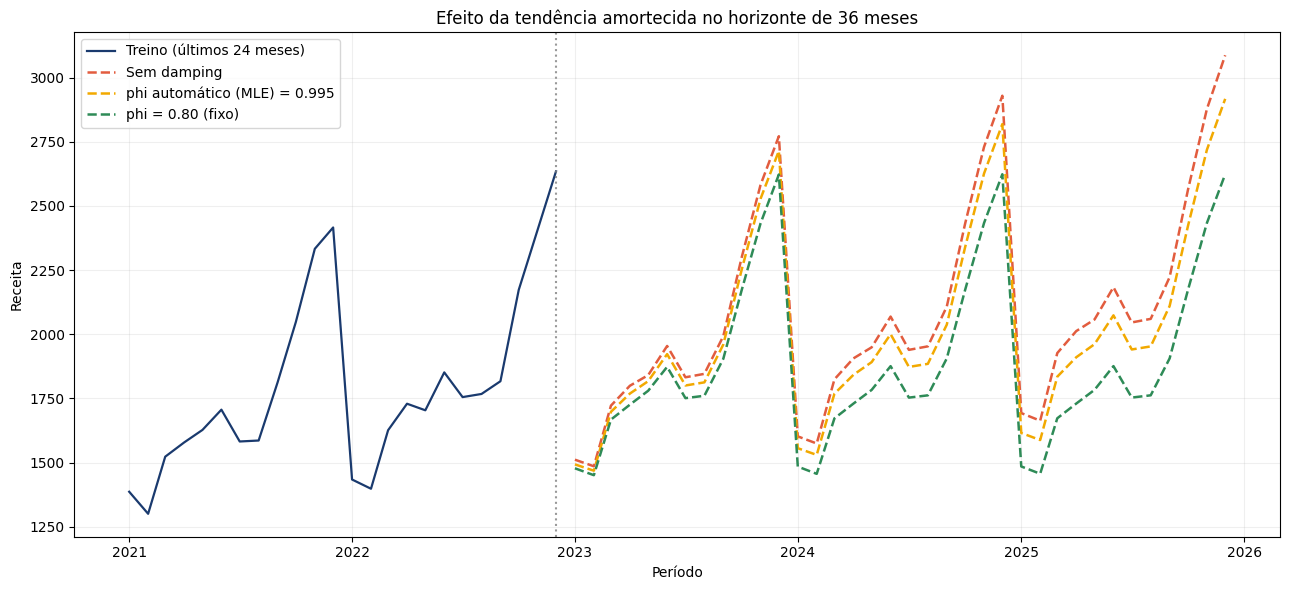

Entre os valores fixos, o menor AIC ocorre em phi=0.99.
Quanto menor phi, maior o amortecimento e mais rapidamente a tendência se estabiliza.


In [15]:
# Curvas pedidas: sem damping, phi automático e phi=0.80
fc_phi_080 = modelos_fixos[0.80][1]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train[-24:].index, train[-24:], label='Treino (últimos 24 meses)',
        color='#1a3a6e', linewidth=1.6)
ax.plot(fc_sem_damping.index, fc_sem_damping, '--', label='Sem damping',
        color='#e25c3e', linewidth=1.8)
ax.plot(fc_mle.index, fc_mle, '--', label=f'phi automático (MLE) = {phi_mle:.3f}',
        color='#f2a900', linewidth=1.8)
ax.plot(fc_phi_080.index, fc_phi_080, '--', label='phi = 0.80 (fixo)',
        color='#2e8b57', linewidth=1.8)
ax.axvline(train.index[-1], color='gray', linestyle=':', alpha=0.8)
ax.set_title('Efeito da tendência amortecida no horizonte de 36 meses')
ax.set_xlabel('Período')
ax.set_ylabel('Receita')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

melhor_aic = tabela_damping.loc[tabela_damping['AIC'].idxmin()]
print(f"Entre os valores fixos, o menor AIC ocorre em phi={melhor_aic['phi']:.2f}.")
print('Quanto menor phi, maior o amortecimento e mais rapidamente a tendência se estabiliza.')